In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# set a random seed for reproducibility 
np.random.seed(0)

# create a time series of 200 points
n = 200
t = np.arange(n)

# create a simple trend of 0.1*t + random noise
data = 0.1 * t + np.random.randn(n)

# convert to pandas series for convenience
s = pd.Series(data)



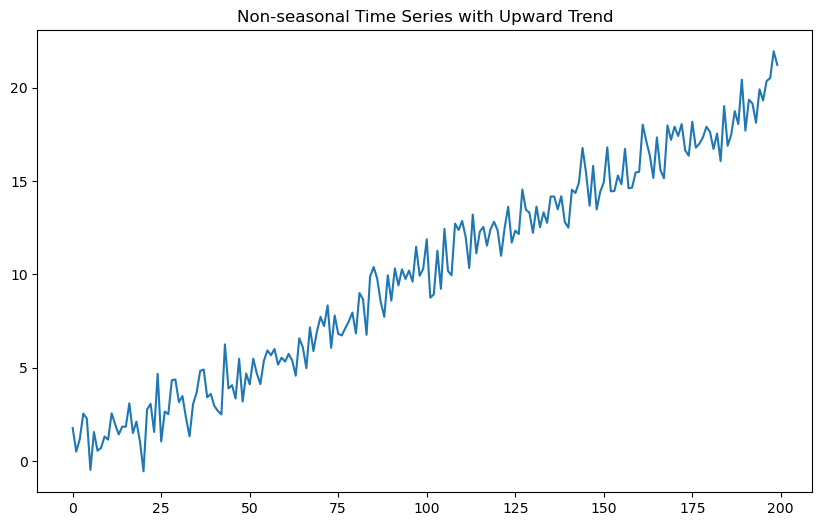

In [2]:
plt.figure(figsize=(10, 6))
plt.plot(s)
plt.title('Non-seasonal Time Series with Upward Trend')
plt.show()

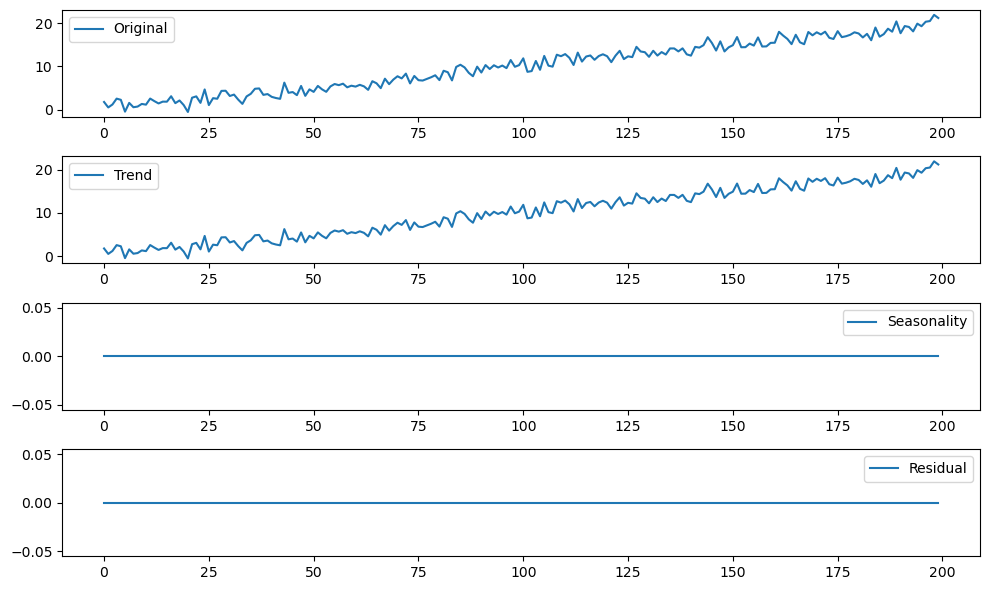

In [11]:
# decompose the data into trend, seasonal, and residual components
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(s, model='additive', period=1)
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

plt.figure(figsize=(10, 6))
plt.subplot(411)
plt.plot(s, label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(seasonal, label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(residual, label='Residual')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

200    21.622241
201    21.417517
202    21.526178
203    21.468504
204    21.499116
205    21.482868
206    21.491492
207    21.486915
208    21.489344
209    21.488054
Name: predicted_mean, dtype: float64


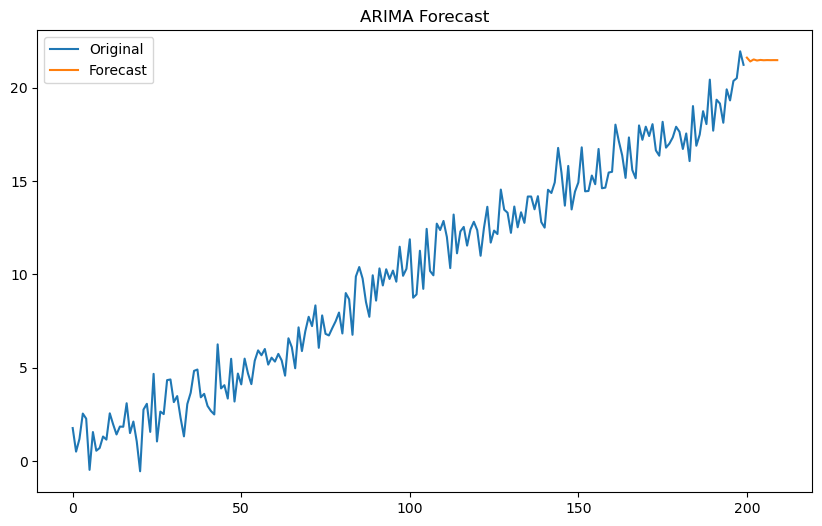

In [12]:
# fit the ARIMA model to the data
model = ARIMA(s, order=(1, 1, 0))
model_fit = model.fit()

# generate a forecast
forecast = model_fit.forecast(steps=10)

# print the forecast
print(forecast)

# plot the original and forecast values
plt.figure(figsize=(10, 6))
plt.plot(s, label='Original')
plt.plot(forecast, label='Forecast')
plt.legend(loc='best')
plt.title('ARIMA Forecast')
plt.show()

# ARIMA model in Python

In [14]:
p, d, q = 5, 1, 2
# put ARIMA model into a function
from  statsmodels.tsa.arima.model import ARIMA
model = ARIMA(s, order=(p, d, q))
model_fit = model.fit()
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(5, 1, 2)   Log Likelihood                -288.641
Date:                Thu, 20 Aug 2026   AIC                            593.282
Time:                        17:35:05   BIC                            619.629
Sample:                             0   HQIC                           603.945
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9248      0.090     10.301      0.000       0.749       1.101
ar.L2          0.0740      0.100      0.742      0.458      -0.121       0.269
ar.L3         -0.0394      0.114     -0.345      0.7

c:\Users\Zone Tech\.conda\envs\tensorflow_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [17]:
import statsmodels.api as sm
import warnings
model = sm.tsa.statespace.SARIMAX(s, order=(1, 1, 0), seasonal_order=(p, d, q, 12))
warnings.filterwarnings('ignore')
model_fit = model.fit()
print(model_fit.summary())

                                        SARIMAX Results                                        
Dep. Variable:                                       y   No. Observations:                  200
Model:             SARIMAX(1, 1, 0)x(5, 1, [1, 2], 12)   Log Likelihood                -306.143
Date:                                 Thu, 20 Aug 2026   AIC                            630.286
Time:                                         17:37:09   BIC                            659.366
Sample:                                              0   HQIC                           642.069
                                                 - 200                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5033      0.071     -7.065      0.000      -0.643      -0

In [19]:
# predict the model
prediction = model_fit.get_forecast(steps=30).predicted_mean
prediction

200    21.045702
201    21.393088
202    21.769357
203    21.832979
204    22.641752
205    21.916858
206    21.790059
207    22.291686
208    22.029746
209    22.007395
210    21.951428
211    23.123005
212    21.832883
213    22.853591
214    22.441939
215    22.563008
216    23.588809
217    23.063871
218    23.123074
219    23.311491
220    23.306903
221    23.505974
222    23.259316
223    23.945261
224    22.955032
225    23.937961
226    23.760619
227    23.907070
228    24.825174
229    24.228391
Name: predicted_mean, dtype: float64

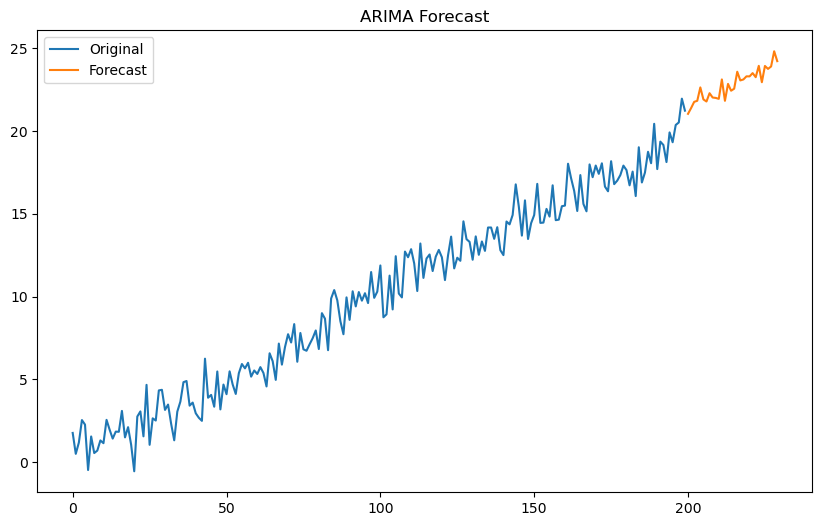

In [20]:
# plot the forecast
plt.figure(figsize=(10, 6))
plt.plot(s, label='Original')
plt.plot(prediction, label='Forecast')
plt.legend(loc='best')
plt.title('ARIMA Forecast')
plt.show()